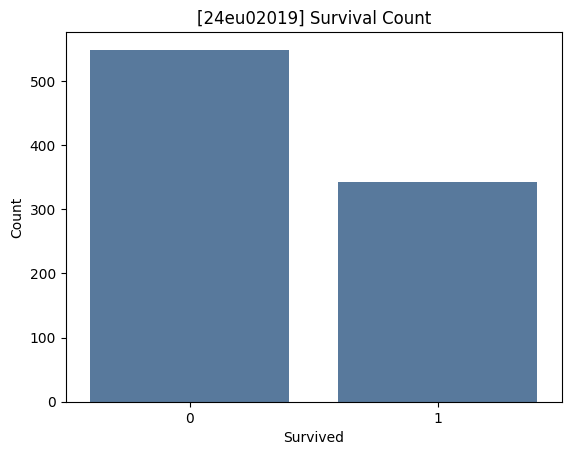

Accuracy: 0.8044692737430168
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       110
           1       0.77      0.71      0.74        69

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



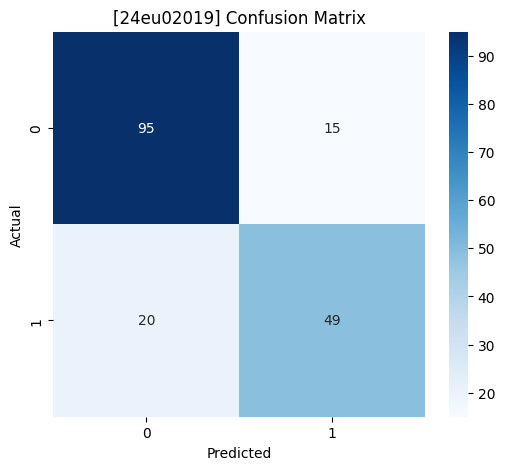

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Load dataset
df = sns.load_dataset("titanic")

# Survival count
sns.countplot(x="survived", data=df, color="#4C78A8")
plt.title("[24eu02019] Survival Count")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()

# Select columns
data = df[
    ["survived", "pclass", "sex", "age", "sibsp", "parch", "fare"]
].copy()

# Encode sex
data["sex"] = LabelEncoder().fit_transform(data["sex"])

# Fill missing values
data["age"] = SimpleImputer(strategy="median").fit_transform(
    data[["age"]]
)

# Features and target
X = data.drop("survived", axis=1)
y = data["survived"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Model
classifier = LogisticRegression(max_iter=1000)
classifier.fit(X_train, y_train)

# Prediction
y_pred = classifier.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Report
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["0", "1"],
    yticklabels=["0", "1"]
)

plt.title("[24eu02019] Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Dataset Shape: (20640, 8)

Features:
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='object')

Training samples: 16512
Testing samples: 4128

Regression Performance:
Mean Absolute Error: 0.5332001304956553
Mean Squared Error: 0.5558915986952444
Root Mean Squared Error: 0.7455813830127764
R2 Score: 0.5757877060324508


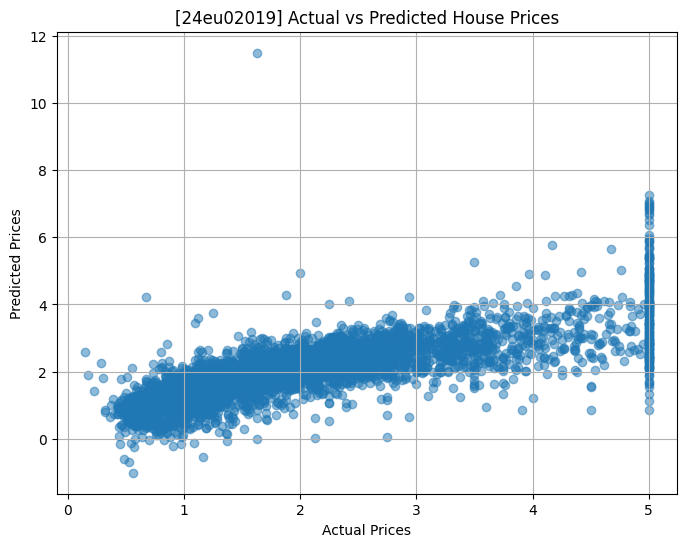

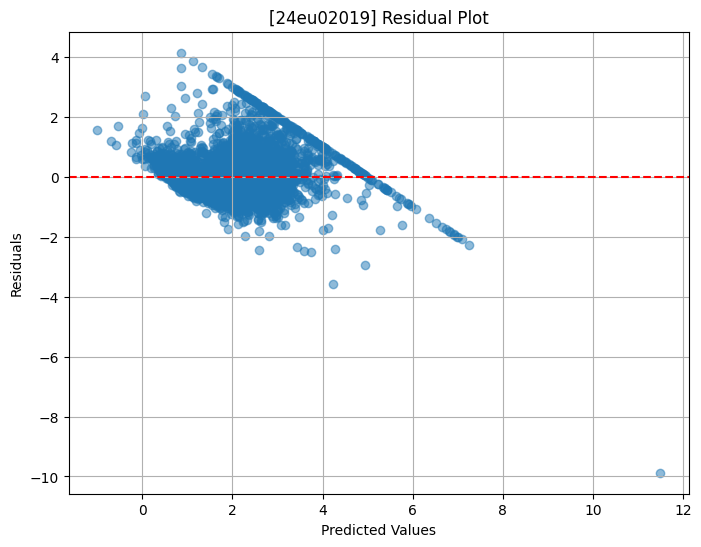

In [4]:
# Regression Task on California Housing Dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ---------------------------------------------------
# 1. Load California Housing Dataset
# ---------------------------------------------------

housing = fetch_california_housing(as_frame=True)

X = housing.data
y = housing.target

print("Dataset Shape:", X.shape)
print("\nFeatures:")
print(X.columns)

# ---------------------------------------------------
# 2. Split Dataset into Training and Testing Sets
# ---------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

# ---------------------------------------------------
# 3. Create Linear Regression Model
# ---------------------------------------------------

model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# ---------------------------------------------------
# 4. Make Predictions
# ---------------------------------------------------

y_pred = model.predict(X_test)

# ---------------------------------------------------
# 5. Calculate Regression Metrics
# ---------------------------------------------------

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nRegression Performance:")
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

# ---------------------------------------------------
# 6. Actual vs Predicted Plot
# ---------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("[24eu02019] Actual vs Predicted House Prices")

plt.grid(True)

plt.show()

# ---------------------------------------------------
# 7. Residual Plot
# ---------------------------------------------------

residuals = y_test - y_pred

plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.5
)

# Zero residual reference line
plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("[24eu02019] Residual Plot")

plt.grid(True)

plt.show()